# makemore: part 3
## activations, gradients and batchnorm

In [1]:
# imports 

import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('assets/names.txt').read().splitlines()

# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print("vocab_size -> ", vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab_size ->  27


## base code (from makemore - part 2)
### with few changes for better readablity.

In [3]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [4]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [5]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 27.8817
  10000/ 200000: 2.8138
  20000/ 200000: 2.5218
  30000/ 200000: 2.7874
  40000/ 200000: 2.0334
  50000/ 200000: 2.6237
  60000/ 200000: 2.3289
  70000/ 200000: 2.0826
  80000/ 200000: 2.2784
  90000/ 200000: 2.2252
 100000/ 200000: 2.0428
 110000/ 200000: 2.3121
 120000/ 200000: 2.0570
 130000/ 200000: 2.4546
 140000/ 200000: 2.2233
 150000/ 200000: 2.1551
 160000/ 200000: 2.0597
 170000/ 200000: 1.7981
 180000/ 200000: 2.0194
 190000/ 200000: 1.7459


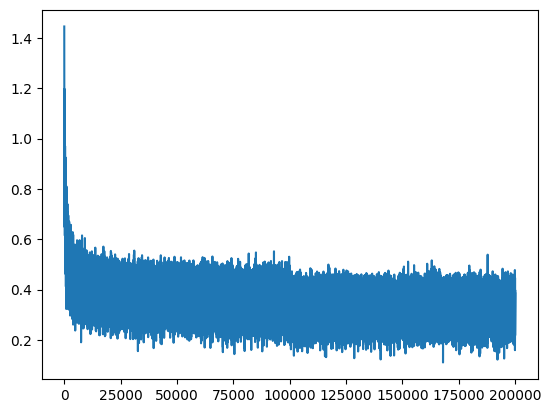

In [6]:
plt.plot(lossi)

In [7]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1267659664154053
val 2.1697638034820557


In [8]:
# we can see that output is much better than bigram model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amorie.
khirmin.
rey.
cassanden.
jazhubedah.
sart.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jore.
quint.
salin.
alianni.
wazthoniearyxi.
jace.
pirran.
eddeci.


## Gaps and optimization in current code

### Initialization loss

- looking at iteration '0' -> `0/ 200000: 27.8817`
  - we are recording a loss of 27.88
  - while building a neural network we have rough idea of loss based on data, loss function, etc
  - here we expect a much lower number. at begineening, the probability should be uniform for all characters -> `1/27` 

In [9]:
# expected log loss
- torch.tensor(1/27.0).log()

tensor(3.2958)

-  at initialization neural is creating messed up probability distribution. some characters are very confident and some are very less confident.
-  the network is very confidently wrong, resulting is very high log loss.

In [10]:
# fixing initialization probablity distribution
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# why not set W2 as zeros?


parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

In [11]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2786
  10000/ 200000: 2.4383
  20000/ 200000: 2.3447
  30000/ 200000: 2.3152
  40000/ 200000: 1.8820
  50000/ 200000: 2.2681
  60000/ 200000: 2.4138
  70000/ 200000: 1.9567
  80000/ 200000: 2.3270
  90000/ 200000: 2.3341
 100000/ 200000: 2.0504
 110000/ 200000: 2.1307
 120000/ 200000: 2.0703
 130000/ 200000: 2.0324
 140000/ 200000: 1.9325
 150000/ 200000: 2.1516
 160000/ 200000: 2.4159
 170000/ 200000: 2.0924
 180000/ 200000: 2.4790
 190000/ 200000: 2.2598


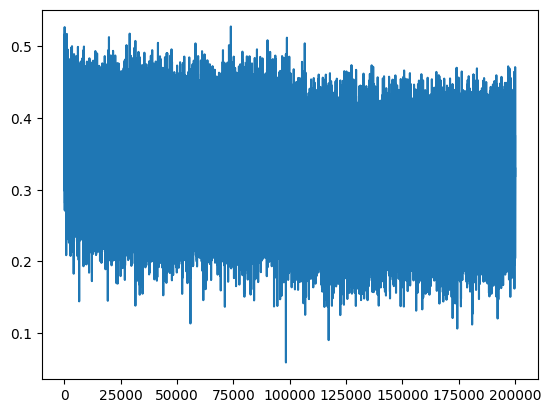

In [12]:
plt.plot(lossi)

In [13]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.070216417312622
val 2.1247506141662598


- in plot, we dont have 'hockey stick' apearance. so network is not spending time squashing the weights in begineening but spending time training and realizing hard gains.
- we have better log loss in train vs eval.

### saturated tanh

- second initialization issue, values of `h` (sctivation of hidden state)
  - looking into `h` tensor, there are many values with 1 or -1

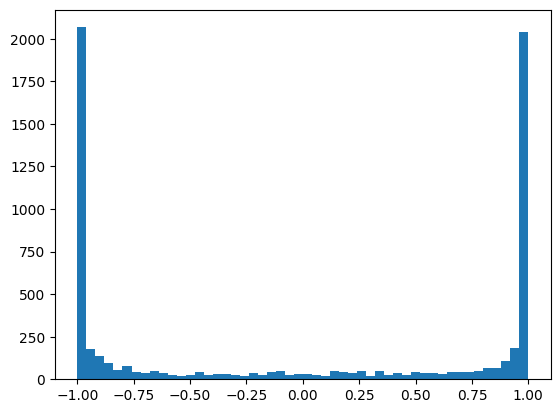

In [14]:
plt.hist(h.view(-1).tolist(), 50);

- `tanh` (h) is a squashing function which squashes the values to either -1 or 1. this means `tanh` is very active.
- looking into preactivation of `h/tanh`

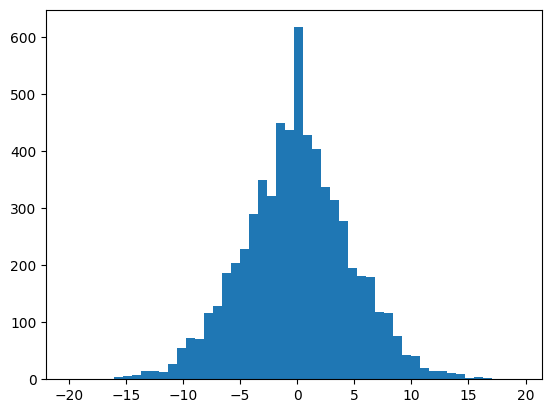

In [15]:
plt.hist(hpreact.view(-1).tolist(), 50);

- we can see hpreact is very very broad, ~`-6-6` . thats why tanh is squashing it to -1, 1.

why is this a issue?
During backpropagation, we are going to backward pass starting at the loss and flowing through the nextwork. We will backward propagate through `tanh`. Looking into micrograd.

```python
import math    
def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1) 
        # out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad = (1 - t**2) * out.grad
        
        out._backward = _backward
        return out
```
what happens if `tanh` is -1 or 1. `(1 - t**2) * out.grad` will be 0 if `t` is ~`1` or ~`-1` no matter what value of `out.grad`. we are killing the gradient.

This makes sense, as this is a tanh neuron and when its output is very close to 1/-1, we are at the tail of tanh

[TODO]: revisit later.


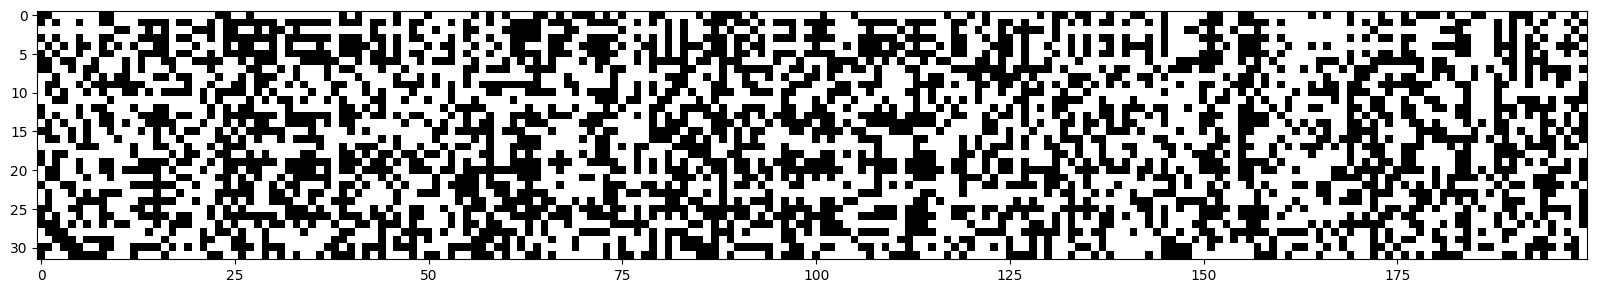

In [16]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest');

- we see lot of white, which are tanh neurons which are very active and are in a flat tail. 
- in all these cases, backward gradient will be destroyed.
- we will be in lot of trouble, if for any of entire the column making it a dead neuron. This neuron will never learn.
- same applies to other activation functions

![image.png](assets/activation_functions.jpg)

In [17]:
# fixing saturated tanh
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)

# we want pre-activation to be closer to 0.
# hpreact = embcat @ W1 + b1

W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01

b2 = torch.randn(vocab_size,                      generator=g) * 0

In [18]:
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

In [19]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3135
  10000/ 200000: 2.1648
  20000/ 200000: 2.3061
  30000/ 200000: 2.4541
  40000/ 200000: 1.9787
  50000/ 200000: 2.2930
  60000/ 200000: 2.4232
  70000/ 200000: 2.0680
  80000/ 200000: 2.3095
  90000/ 200000: 2.1207
 100000/ 200000: 1.8269
 110000/ 200000: 2.2045
 120000/ 200000: 1.9797
 130000/ 200000: 2.3946
 140000/ 200000: 2.1000
 150000/ 200000: 2.1948
 160000/ 200000: 1.8619
 170000/ 200000: 1.7809
 180000/ 200000: 1.9673
 190000/ 200000: 1.8295


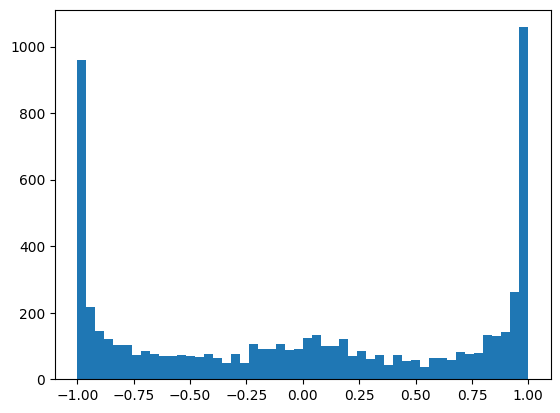

In [20]:
plt.hist(h.view(-1).tolist(), 50);

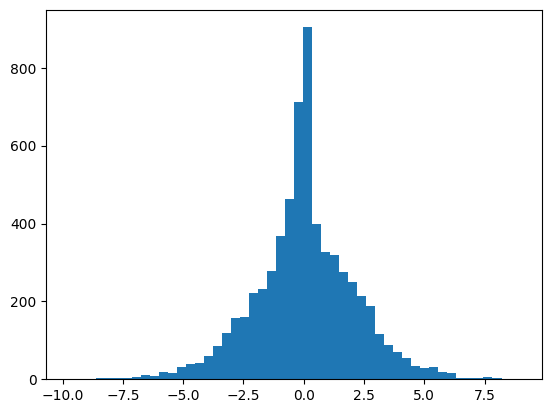

In [21]:
plt.hist(hpreact.view(-1).tolist(), 50);

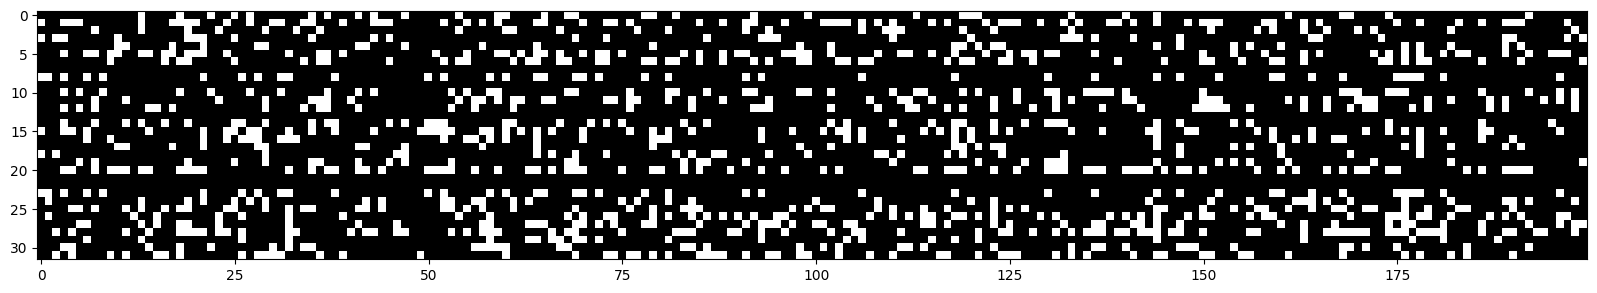

In [22]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest');

train and val log loss

In [23]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0355966091156006
val 2.1026782989501953


### kaiming init

looking into our improvements:
```python
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
```
how do we come up with numbers like 0.01, 0.1, 0.2? 


tensor(0.0005) tensor(1.0064)
tensor(0.0021) tensor(3.1516)


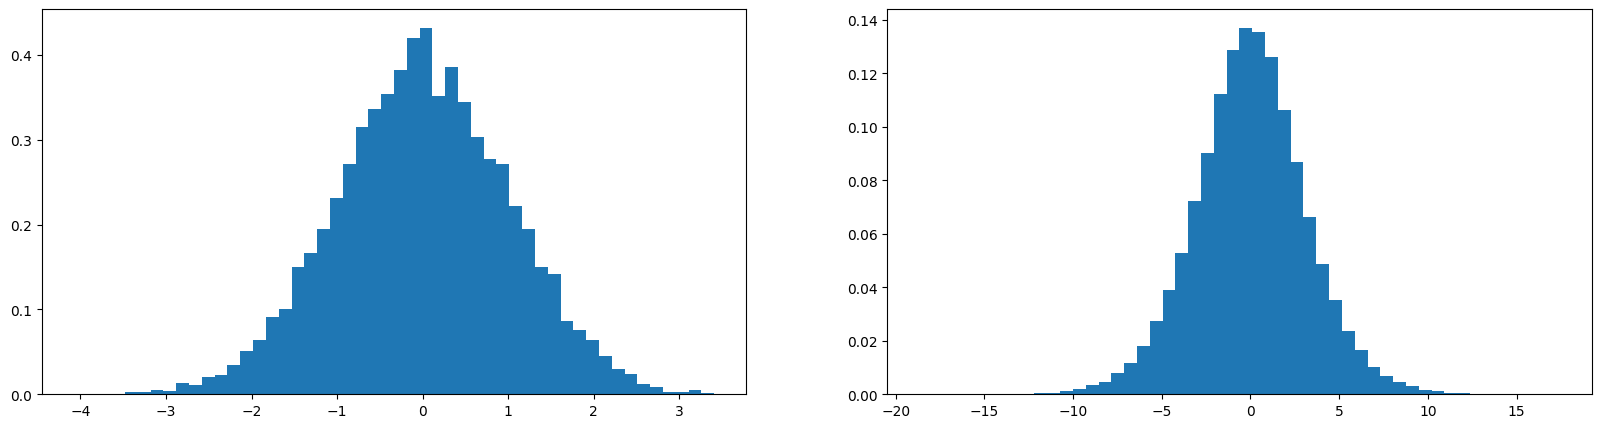

In [24]:
x = torch.randn(1000, 10) # randon input drawn from gaussian, 1000 examples and 10 dimensions
w = torch.randn(10, 200) # weights drawn from gaussian, 10 input dimensions and 200 output dimensions (neurons)
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

whats the mean and standard deviation of these gaussion (x, y):
- x -> input mean ~0, standard deviation 1
- y (x @ w) -> output mean ~0, standard deviation has expanded to 3

we can see below that multiplying with large number, standard deviation expands but shrinks with smaller value.


In [25]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * 5
y = x @ w

print('x -> mean: ', x.mean(), 'std. deviation: ', x.std())
print('y * 5 -> mean: ', y.mean(), 'std. deviation: ', y.std())

print('------')
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * 0.2
y = x @ w

print('x -> mean: ', x.mean(), 'std. deviation: ', x.std())
print('y * 5 -> mean: ', y.mean(), 'std. deviation: ', y.std())

x -> mean:  tensor(-0.0021) std. deviation:  tensor(1.0043)
y * 5 -> mean:  tensor(0.0434) std. deviation:  tensor(16.0142)
------
x -> mean:  tensor(0.0093) std. deviation:  tensor(0.9954)
y * 5 -> mean:  tensor(-0.0007) std. deviation:  tensor(0.6298)


whats the current value to preserve the standard deviation of 1?

if we calculate it mathematically, the correct value is "devide by square root of fan-in". fan-in is no of input elements, which is 10 here.

In [26]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w

print('x -> mean: ', x.mean(), 'std. deviation: ', x.std())
print('y / 10**0.5 (sqrt)-> mean: ', y.mean(), 'std. deviation: ', y.std())

x -> mean:  tensor(0.0091) std. deviation:  tensor(0.9954)
y / 10**0.5 (sqrt)-> mean:  tensor(-0.0031) std. deviation:  tensor(0.9861)


There are many papers on initializing neural networks. One important one is by Kaiming He, titled "Delving Deep Into Rectifiers", also called "Kaiming Init".

In paper, they study CNN and ReLU and PReLU non-linearity but analysis is very similar and useful for others like tanh.

Kaiming Initialization is also implemented in Pytorch.

In recent time, it has become less important to precisely initialize neural networks due to modern innovations like
- "residural connections"
- use of normalization layers like batch normalization, layer normalization
- much better optimizers like ADAM (Adaptive Moment Estimation), ARS (Augmented Random Search) etc

In [27]:
# we want to set standard deviation to gain / sqrt(fan_in)

# gain for tanh -> 5/3
# fan_in = n_embd * block_size (for W1)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2

## ----------------------------
C  = torch.randn((vocab_size, n_embd),            generator=g)
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True
## ----------------------------

11897


In [28]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3260
  10000/ 200000: 2.3233
  20000/ 200000: 2.2795
  30000/ 200000: 1.8691
  40000/ 200000: 1.8211
  50000/ 200000: 2.2640
  60000/ 200000: 1.7722
  70000/ 200000: 1.8635
  80000/ 200000: 2.1621
  90000/ 200000: 1.8722
 100000/ 200000: 1.8365
 110000/ 200000: 2.0416
 120000/ 200000: 2.1155
 130000/ 200000: 2.2402
 140000/ 200000: 1.9133
 150000/ 200000: 2.2652
 160000/ 200000: 1.8316
 170000/ 200000: 2.2104
 180000/ 200000: 1.7895
 190000/ 200000: 1.8145


In [29]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0407228469848633
val 2.1027934551239014


we reached the same loss but without hardcoding. 

## Batch Normalization

This is based on "Batch Normalization" paper from Team at Google.

We have hidden state, `hpreact` which should be roughly gaussian. If they are small, then tanh is inactive but its very large, tanh is saturated and gradients dont flow.

The insight from paper is, we can standardise the activations of the hidden states to be gaussian.


In [30]:
print(hpreact.shape) # size is 32, 200
# we can calculate hpreact means on 0th dimension, doing it over all the elemments in the batch
hpreact.mean(0, keepdim=True).shape, hpreact.std(0, keepdim=True).shape

torch.Size([32, 200])


(torch.Size([1, 200]), torch.Size([1, 200]))

implementing batch normalization from paper https://arxiv.org/pdf/1502.03167.pdf

![](assets/batch_normalization.png)

```python
hpreact = embcat @ W1 + b1 # hidden layer pre-activation
hpreact_mean = hpreact.mean(0, keepdim=True)
hpreact_std = hpreact.std(0, keepdim=True)
hpreact = hpreact - hpreact_mean / hpreact_std
```
this will actually not have good results as we want hpreact to be roughly gaussian at start but dont want to force to be gaussian always.

backprogagation should tell how to update batch normalization parameters.

BatchNorm parameters
```python
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
```

during back-propagation, we will change bngain and bnbias.
```python
hpreact = bngain * (hpreact - hpreact_mean) / hpreact_std + bnbias
```

In [31]:
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


In [32]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  hpreact_mean = hpreact.mean(0, keepdim=True)
  hpreact_std = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - hpreact_mean) / hpreact_std + bnbias
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.2971
  10000/ 200000: 2.0458
  20000/ 200000: 2.3129
  30000/ 200000: 2.1880
  40000/ 200000: 2.1209
  50000/ 200000: 2.7382
  60000/ 200000: 1.8430
  70000/ 200000: 2.6443
  80000/ 200000: 2.0013
  90000/ 200000: 1.9999
 100000/ 200000: 1.9850
 110000/ 200000: 1.8819
 120000/ 200000: 1.5603
 130000/ 200000: 2.3070
 140000/ 200000: 2.0365
 150000/ 200000: 2.2149
 160000/ 200000: 2.1877
 170000/ 200000: 2.3028
 180000/ 200000: 2.1686
 190000/ 200000: 1.8395


In [33]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  # doing the same thing at test time
  hpreact_mean = hpreact.mean(0, keepdim=True)
  hpreact_std = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - hpreact_mean) / hpreact_std + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.066291332244873
val 2.1078851222991943


we are not expecting a measurable gain as we are dealing with very simple neural network but batch normalization will become important as network grows with lots of diff times of operations.

One thing to note that, due to batch normalization, we are coupling the examples mathematically cross forward pass and backward pass. Now, hidden state activations for any example is going to be affected by other examples in batch as those examples affect mean and std deviation. We will get jitters for h, logits.
This is actually benificial for neural network, it works as a regularlizer and its introducing a entropy making neural network to overfit a single example.

There are other normalization techniques that dont couple examples like layer, group etc.

### calculating updating mean and standard daviation

Once we have trained a neural network, we want to feed single example and get a result but with back normalization, it expacts a batch.

First proposal is, we will have a step after training which caculates and sets batch norms params and it will be fixed for inference time.

Second ideas is, to calculate batch norm params (mean and std deviation) in running manner while training. 


In [34]:
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))

# for running mean and std deviation
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
for p in parameters:
  p.requires_grad = True

In [35]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  
  hpreact = embcat @ W1 + b1 # hidden layer pre-activation
  hpreact_mean = hpreact.mean(0, keepdim=True)
  hpreact_std = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - hpreact_mean) / hpreact_std + bnbias
  
  # they are not part of gradiant computation, so we can use torch.no_grad()
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * hpreact_mean
    bnstd_running = 0.999 * bnstd_running + 0.001 * hpreact_std

  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3126
  10000/ 200000: 2.1470
  20000/ 200000: 2.3701
  30000/ 200000: 1.9580
  40000/ 200000: 2.2956
  50000/ 200000: 1.8196
  60000/ 200000: 1.9319
  70000/ 200000: 2.0864
  80000/ 200000: 2.7170
  90000/ 200000: 2.6637
 100000/ 200000: 1.9874
 110000/ 200000: 2.3385
 120000/ 200000: 2.4399
 130000/ 200000: 2.3295
 140000/ 200000: 1.9786
 150000/ 200000: 2.3090
 160000/ 200000: 1.9270
 170000/ 200000: 2.2164
 180000/ 200000: 2.0567
 190000/ 200000: 2.0051


In [36]:
# calibrate the batch norm at the end of training (first proposal)

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [37]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0688717365264893
val 2.1084296703338623


we can check that:
- bnstd_running ~= bnstd
- bnmean_running ~= bnmean

In [38]:
bnstd_running

tensor([[2.1144, 2.0346, 2.0657, 2.2742, 2.0395, 2.2958, 1.9202, 2.1761, 2.4735,
         2.0239, 1.8881, 2.4292, 2.3645, 1.6448, 2.2624, 2.1225, 2.4174, 1.9833,
         2.4564, 1.9681, 2.0512, 2.1091, 1.7833, 2.0016, 2.0210, 2.2120, 2.1133,
         2.2810, 1.7041, 2.0232, 1.9735, 1.5950, 2.2603, 1.8229, 1.8651, 2.1462,
         2.4217, 2.0473, 2.0688, 2.1407, 1.9066, 1.7719, 2.2065, 2.1981, 2.2759,
         2.2125, 1.3549, 1.9600, 2.0741, 2.3053, 2.6231, 2.0709, 1.7650, 2.1681,
         1.6354, 2.2338, 2.3274, 1.9579, 2.1342, 1.9046, 2.1796, 2.4810, 2.4279,
         2.0147, 1.6648, 1.9018, 1.9539, 1.9013, 1.9688, 1.9590, 1.9137, 2.2921,
         2.0118, 2.1737, 2.2068, 1.8472, 1.8741, 2.0820, 2.7054, 2.0262, 2.1043,
         2.1020, 1.7977, 2.0844, 1.9305, 2.2491, 1.7520, 2.3290, 2.3603, 1.9690,
         2.1602, 2.2322, 1.7603, 2.1090, 2.1988, 2.1754, 2.0382, 2.2809, 2.1410,
         2.4614, 2.2694, 2.1833, 2.4406, 1.3531, 2.1794, 2.3263, 2.3711, 2.2538,
         2.0052, 2.2661, 1.9

In [39]:
bnstd

tensor([[2.1422, 2.0572, 2.1020, 2.2804, 2.0753, 2.3249, 1.9358, 2.2177, 2.5244,
         2.0383, 1.9209, 2.4506, 2.4123, 1.6636, 2.2829, 2.1447, 2.4218, 2.0058,
         2.4765, 1.9848, 2.0748, 2.1268, 1.7974, 2.0156, 2.0417, 2.2335, 2.1438,
         2.2949, 1.7236, 2.0424, 1.9850, 1.6068, 2.2812, 1.8522, 1.8875, 2.1669,
         2.4453, 2.0701, 2.0898, 2.1548, 1.9326, 1.7943, 2.2226, 2.2421, 2.3008,
         2.2466, 1.3753, 1.9710, 2.0918, 2.3132, 2.6397, 2.0903, 1.7759, 2.2034,
         1.6519, 2.2376, 2.3625, 1.9772, 2.1541, 1.9341, 2.1951, 2.4812, 2.4477,
         2.0295, 1.6946, 1.9343, 1.9666, 1.9254, 1.9845, 1.9774, 1.9371, 2.3073,
         2.0353, 2.2063, 2.2412, 1.8734, 1.8873, 2.0977, 2.7280, 2.0496, 2.1273,
         2.1149, 1.8165, 2.1033, 1.9519, 2.2733, 1.7711, 2.3390, 2.3729, 2.0117,
         2.1744, 2.2500, 1.7755, 2.1380, 2.2251, 2.2030, 2.0669, 2.3141, 2.1633,
         2.4872, 2.2980, 2.1995, 2.4679, 1.3763, 2.1900, 2.3410, 2.4018, 2.2736,
         2.0175, 2.2851, 1.9

In [40]:
# comparing mean and std from both ways
bnmean, bnmean_running

(tensor([[-0.2608,  0.9546,  1.5251, -0.6140,  2.4851, -1.7934,  0.1922,  1.3216,
          -0.4776, -1.5387, -0.6782,  1.3162, -0.2319, -0.0749, -0.1785, -1.0979,
          -1.4168,  1.2333, -0.3715,  0.1958, -0.0136,  0.1010, -1.1190,  1.1019,
          -1.6811,  0.2955,  2.0123, -0.4288, -0.3992,  0.8293,  0.5209, -1.1464,
           0.5923,  0.7287,  0.0525, -0.7447, -0.2051, -1.2028,  0.8030,  0.1272,
           0.5029, -1.4110, -0.5305, -0.7396,  0.6577,  1.4622, -1.9026,  0.3115,
           0.1490, -1.8768,  0.2850,  0.5416, -0.1274,  0.1880,  1.5268, -1.3270,
           1.7069,  0.3157, -0.9930, -1.5258, -1.7643,  3.4200,  0.2627,  1.2447,
           0.4018,  0.6483, -0.5100, -0.5584, -1.0159, -1.4970, -1.4305,  1.0008,
          -0.2714,  0.0407, -1.1154, -1.8737, -1.0315,  0.3617, -0.0802, -0.6328,
          -1.7095,  1.0177, -2.2121,  1.7460,  0.2924, -0.0926,  1.1229,  0.1058,
           0.1851,  0.0754,  1.4720, -1.2024,  1.2151, -0.7644, -0.4712,  1.2520,
          -0.098

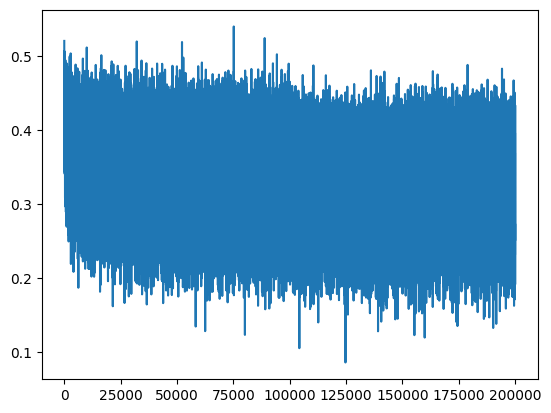

In [41]:
plt.plot(lossi)

using bnmean_running/bnstd_running

In [42]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1  + b1
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0688717365264893
val 2.1084296703338623


final two improvement:
- in normalize, we have `+ε` which we have not used in above model. Its generally a posivite small number preventing divide by zero. Omitted in our case as its not going to happen for this small model.
- bias `+b1` is useless as they are going to be substracted in batch norm (when we calculate mean and substract it). when using batch norm, we can just not use bias. Batch norm has its own bias `bnbias`

### cleaning up code using all improvements and fixes

In [43]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
  # (adding b1 is useless. as we are calculating mean and then sustracting bnmeni
  # and does not have any effect. we have batchnorm bias as `bnbias`.
  # To confirm, if we check gradiant of b1, it will be 0) 
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [44]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
  # BatchNorm layer
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


In [45]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056838035583496


## Pytorch-fing code

In [46]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in**0.5)
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] if self.bias is None else [self.weight, self.bias]
    
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.Training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculate the forward pass
        if self.Training:
            xmean = x.mean(0, keepdim=True) # mean over batch
            xvar = x.var(0, keepdim=True) # variance over batch
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        if self.Training:
            # update running mean and variance
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [89]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.01
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= (5/3)

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True


172697


In [90]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        embcat = layer(embcat)
    loss = F.cross_entropy(embcat, Yb) # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    if i > 10000:
        break

      0/ 200000: 3.2952
  10000/ 200000: 1.9686


layer 1 (      Tanh): mean +0.04, std 0.77, saturated: 23.31%
layer 3 (      Tanh): mean +0.02, std 0.79, saturated: 25.48%
layer 5 (      Tanh): mean -0.04, std 0.82, saturated: 29.92%
layer 7 (      Tanh): mean +0.02, std 0.84, saturated: 32.33%
layer 9 (      Tanh): mean +0.01, std 0.69, saturated: 13.12%


Text(0.5, 1.0, 'activation distribution')

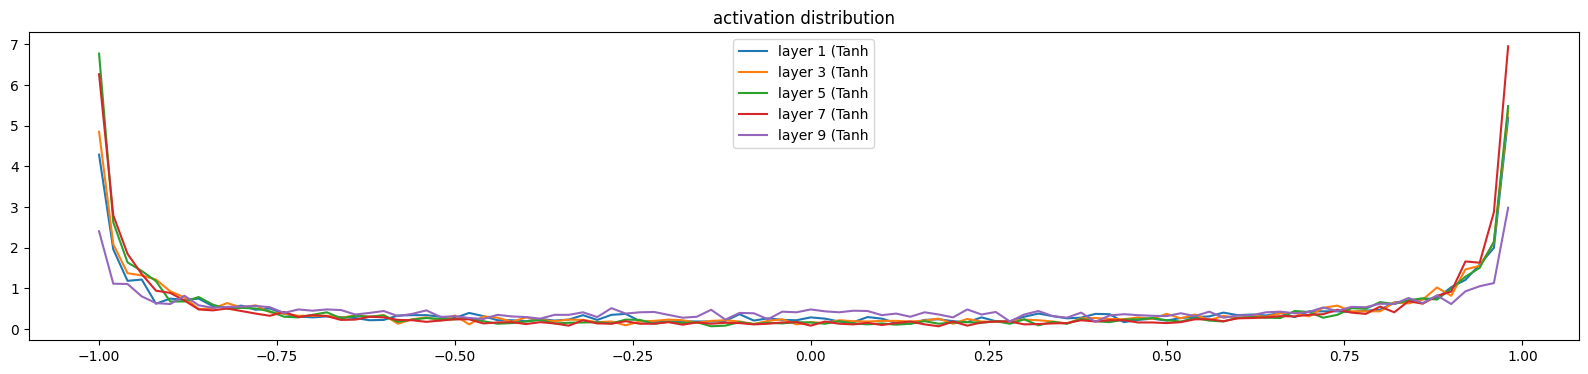

In [91]:
from matplotlib import legend


plt.figure(figsize=(20, 4)) # width, height
legends = []
for i, layer in enumerate(layers[:-1]): # excluding the last layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')


layer 1 (      Tanh): mean +0.000033, std 1.915086e-03
layer 3 (      Tanh): mean -0.000024, std 1.763527e-03
layer 5 (      Tanh): mean -0.000017, std 1.860011e-03
layer 7 (      Tanh): mean -0.000014, std 2.266235e-03
layer 9 (      Tanh): mean -0.000013, std 2.236096e-03


Text(0.5, 1.0, 'gradient distribution')

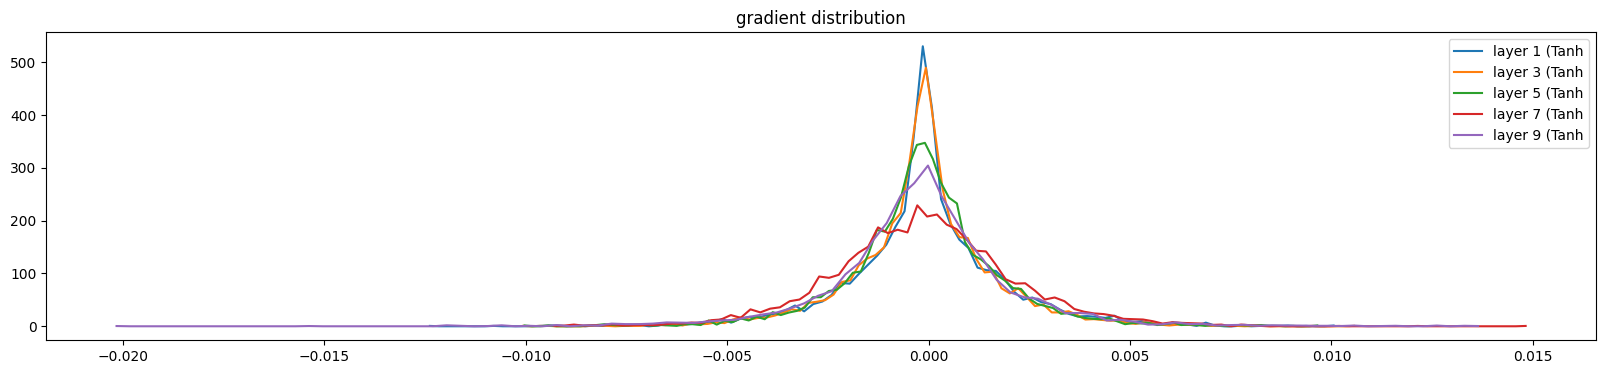

In [92]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000095 | std 1.184127e-02 | grad:data ratio 1.130865e-02
weight  (30, 200) | mean -0.000058 | std 6.142528e-03 | grad:data ratio 1.906013e-02
weight (200, 200) | mean +0.000009 | std 4.070205e-03 | grad:data ratio 3.177594e-02
weight (200, 200) | mean -0.000004 | std 4.016158e-03 | grad:data ratio 3.170896e-02
weight (200, 200) | mean +0.000028 | std 4.313483e-03 | grad:data ratio 3.425420e-02
weight (200, 200) | mean +0.000008 | std 5.214616e-03 | grad:data ratio 4.363114e-02
weight  (200, 27) | mean +0.000000 | std 2.412086e-02 | grad:data ratio 3.209418e-01


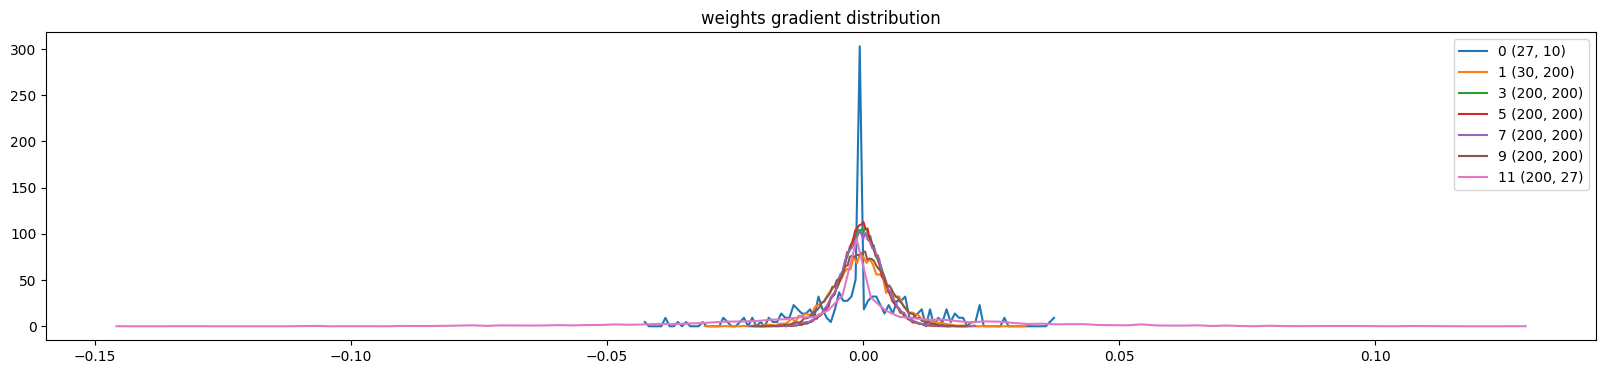

In [93]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

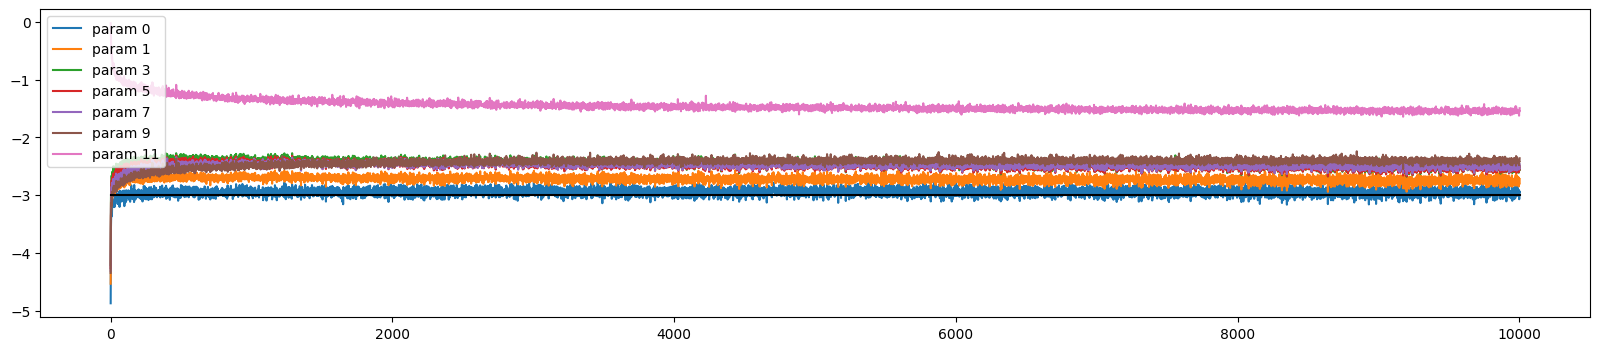

In [94]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

Lets introduce batch norm layer

In [95]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    layers[-1].gamma *= 0.01
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= (5/3)

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

174751


In [96]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        embcat = layer(embcat)
    loss = F.cross_entropy(embcat, Yb) # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    if i > 10000:
        break

      0/ 200000: 3.2950
  10000/ 200000: 2.1182


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 4.09%
layer 5 (      Tanh): mean -0.00, std 0.64, saturated: 4.05%
layer 8 (      Tanh): mean +0.01, std 0.65, saturated: 3.62%
layer 11 (      Tanh): mean +0.01, std 0.66, saturated: 3.28%
layer 14 (      Tanh): mean +0.00, std 0.67, saturated: 2.38%


Text(0.5, 1.0, 'activation distribution')

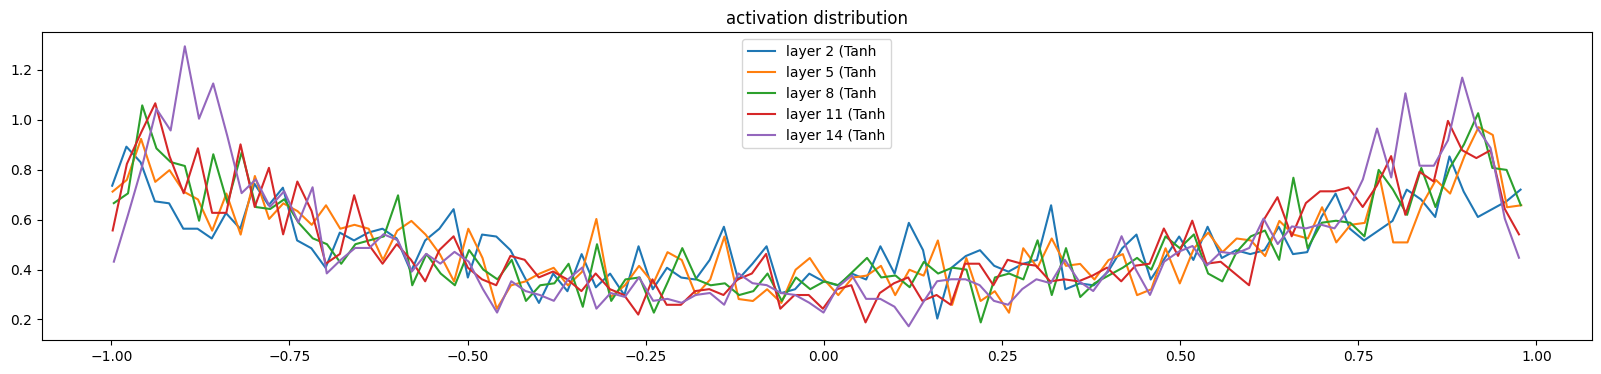

In [97]:
from matplotlib import legend


plt.figure(figsize=(20, 4)) # width, height
legends = []
for i, layer in enumerate(layers[:-1]): # excluding the last layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')


layer 2 (      Tanh): mean -0.000000, std 2.073686e-03
layer 5 (      Tanh): mean -0.000000, std 1.923047e-03
layer 8 (      Tanh): mean -0.000000, std 1.894727e-03
layer 11 (      Tanh): mean -0.000000, std 1.788159e-03
layer 14 (      Tanh): mean +0.000000, std 1.792592e-03


Text(0.5, 1.0, 'gradient distribution')

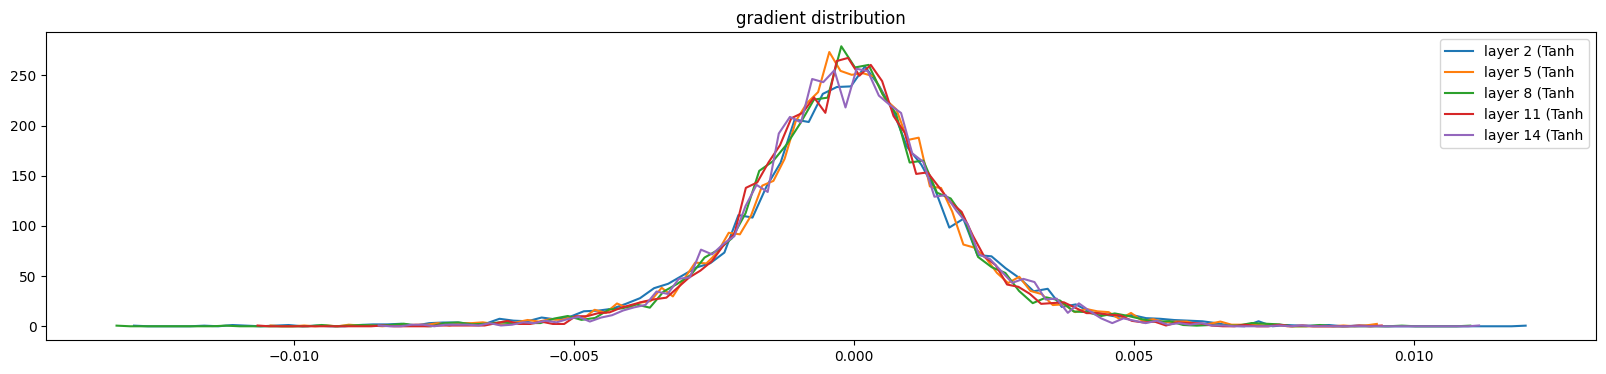

In [98]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.206575e-02 | grad:data ratio 1.199131e-02
weight  (30, 200) | mean +0.000025 | std 5.317621e-03 | grad:data ratio 1.689386e-02
weight (200, 200) | mean -0.000026 | std 3.788075e-03 | grad:data ratio 3.068426e-02
weight (200, 200) | mean +0.000002 | std 3.581042e-03 | grad:data ratio 2.928444e-02
weight (200, 200) | mean -0.000000 | std 3.351986e-03 | grad:data ratio 2.739695e-02
weight (200, 200) | mean +0.000021 | std 3.127726e-03 | grad:data ratio 2.583013e-02
weight  (200, 27) | mean -0.000048 | std 9.287044e-03 | grad:data ratio 6.540349e-02


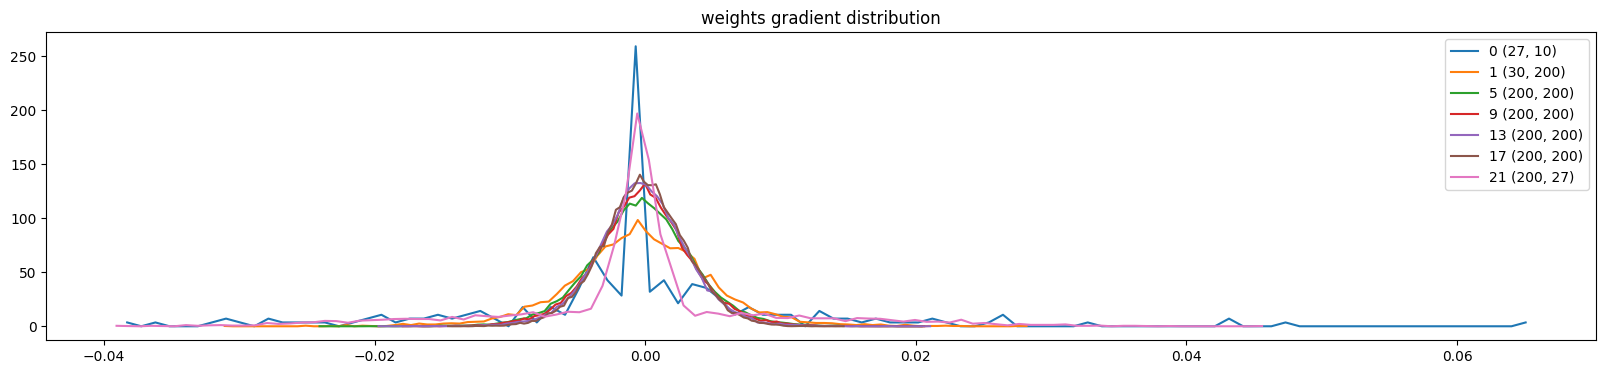

In [99]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

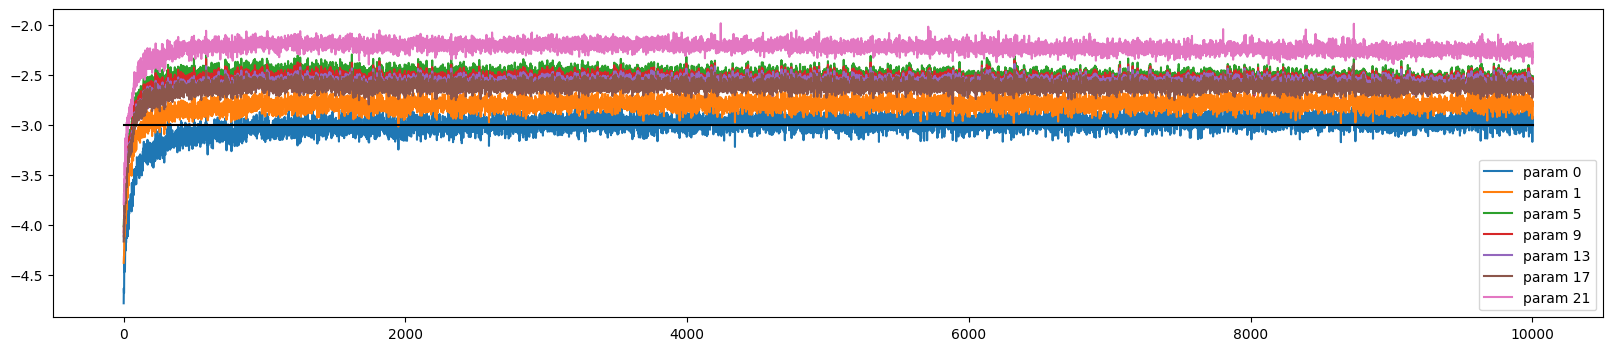

In [100]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);